In [126]:
import blackjack.blackjack as blackjack
import bayesian_agent.bayesian as bayes
import bayesian_agent.markovian as markov
import numpy as np
import matplotlib.pyplot as plt
import importlib

importlib.reload(blackjack)
importlib.reload(bayes)
importlib.reload(markov)

<module 'bayesian_agent.markovian' from '/Users/Hugo/Coding_Projects/UCSD/CSE150A/cse150a-blackjack-inference/bayesian_agent/markovian.py'>

In [125]:
def evaluate(data, agent, num_bots):
    markov.mse = 0
    record = 0
    bot_record = 0
    games_played = 0

    # plays a total of 100,000 games
    for i in range(0, 1000):
        markov.belief = None
        wins, ties, losses, bot_wins, bot_ties, bot_losses = blackjack.play_blackjack(agent, data, num_bots)
        record += wins - losses

        bot_record += bot_wins - bot_losses
        games_played += 100

    print("Number of bots:", num_bots)
    print("Agent:", agent)
    print("Agent record:", record / games_played)
    print("Bot record:", bot_record / (games_played * max(num_bots, 1)))
    print("MSE:", markov.mse / games_played)
    print()

def evaluate_time_series(data, agent, num_bots, num_series = 10, bucket_size = 1):
    markov.mse = 0
    agent_record = np.float32([0] * int(100 / bucket_size))
    bot_record = np.float32([0] * 100)
    belief_record = np.float32([0] * 100)
    mse_record = np.float32([0] * int(100 / bucket_size))

    # plays a total of 100 * num_series games
    for i in range(0, num_series):
        markov.belief = None
        a, b, c, d = blackjack.play_blackjack_time_series(agent, data, num_bots, bucket_size=bucket_size)
        bot_record += np.float32(a)
        agent_record += np.float32(b)
        belief_record += np.float32(c)
        mse_record += np.float32(d)

    print("Number of bots:", num_bots)
    print("Agent:", agent)
    print("Agent record:", np.sum(agent_record) / 100 / num_series)
    if num_bots > 0:
        print("Bot record:", np.sum(bot_record) / 100 / num_series / num_bots)
    print("MSE:", markov.mse / 100 / num_series)
    print("time...:", agent_record)
    plot_time_series(agent_record / num_series / bucket_size, t = int(100 / bucket_size))
    print()

def plot_time_series(agent_record, t = 100):
    x = range(0, t)
    fig = plt.figure()
    ax1 = fig.add_subplot(111)

    ax1.plot(x, agent_record, label='agent record')
        
    plt.legend(loc='upper left')
    plt.show()

Number of bots: 0
Agent: <function markovian_agent1 at 0x12a7b1d00>
Agent record: -0.06088
MSE: 15.74256
time...: [-739. -819. -670. -517. -537. -660. -556. -700. -525. -365.]


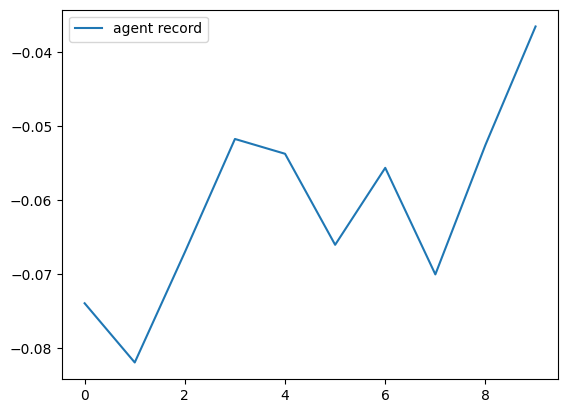


Number of bots: 1
Agent: <function markovian_agent1 at 0x12a7b1d00>
Agent record: -0.06064
Bot record: -0.05296
MSE: 9.39293
time...: [-574. -664. -629. -631. -561. -749. -521. -557. -494. -684.]


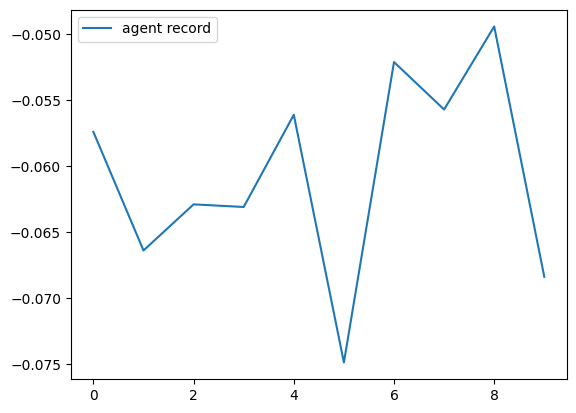


Number of bots: 2
Agent: <function markovian_agent1 at 0x12a7b1d00>
Agent record: -0.05526
Bot record: -0.051815
MSE: 6.04858
time...: [-653. -519. -605. -632. -471. -449. -512. -445. -622. -618.]


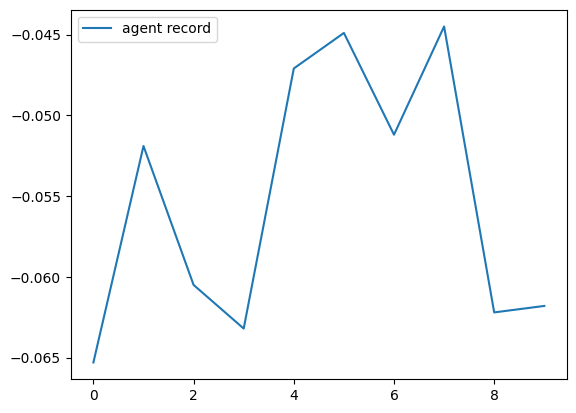


Number of bots: 5
Agent: <function markovian_agent1 at 0x12a7b1d00>
Agent record: -0.04891
Bot record: -0.049838
MSE: 2.5867600000000004
time...: [-331. -551. -655. -567. -400. -383. -568. -461. -457. -518.]


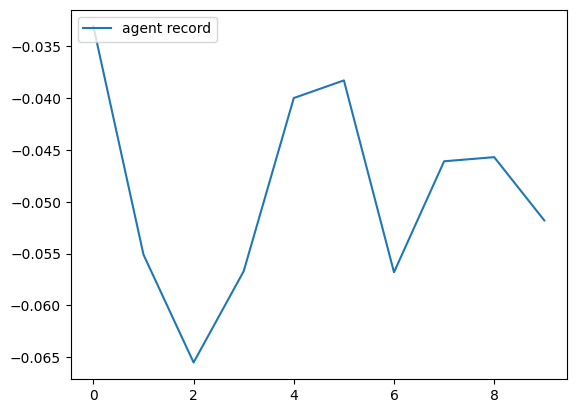


Number of bots: 10
Agent: <function markovian_agent1 at 0x12a7b1d00>
Agent record: -0.055060003
Bot record: -0.054324
MSE: 1.7961099999999999
time...: [-694. -432. -494. -691. -738. -471. -308. -566. -564. -548.]


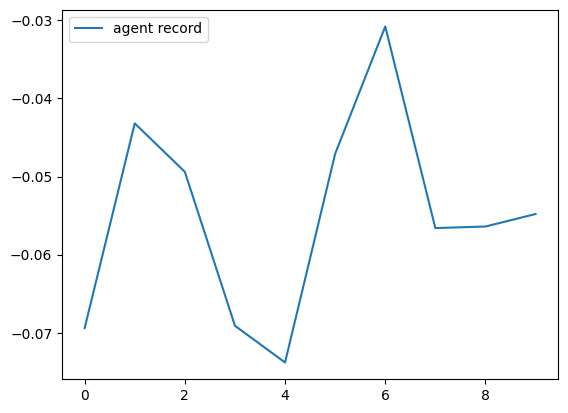

In [104]:
# agent 1
data = blackjack.read_data("blkjck_clean.csv")
for num_bots in [0, 1, 2, 5, 10]:
    evaluate_time_series(data, markov.markovian_agent1, num_bots, num_series=1000, bucket_size=10)

Number of bots: 0
Agent: <function markovian_agent2 at 0x12a7b37e0>
Agent record: 0.0096700005
MSE: 4.12389
time...: [104. 106. 121. 192. -52. 118.  59.  -4. 204. 119.]


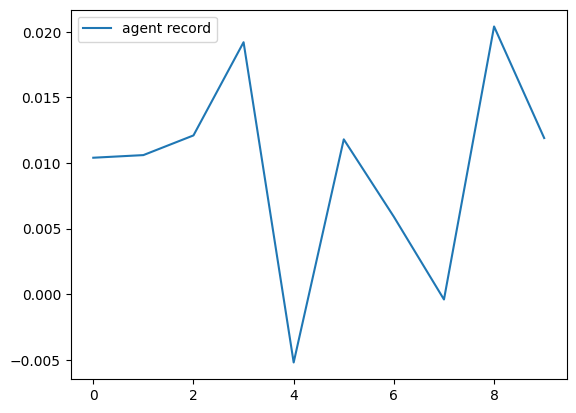


Number of bots: 1
Agent: <function markovian_agent2 at 0x12a7b37e0>
Agent record: 0.01646
Bot record: -0.00797
MSE: 3.37107
time...: [152. 293.  70. 214. 138. 270. 306. 162. 138. -97.]


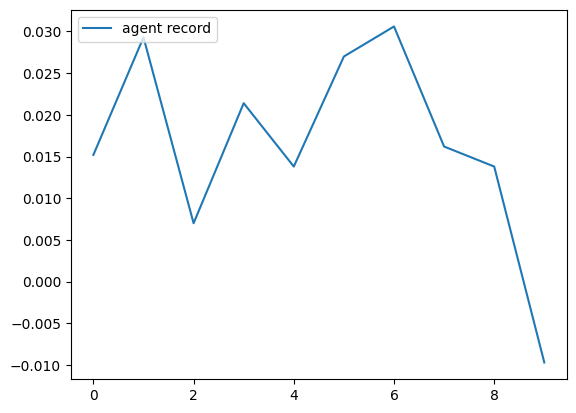


Number of bots: 2
Agent: <function markovian_agent2 at 0x12a7b37e0>
Agent record: 0.01214
Bot record: -0.0042
MSE: 2.74779
time...: [ 25. 145. 154. 160. 109. 138. 175. 101.  88. 119.]


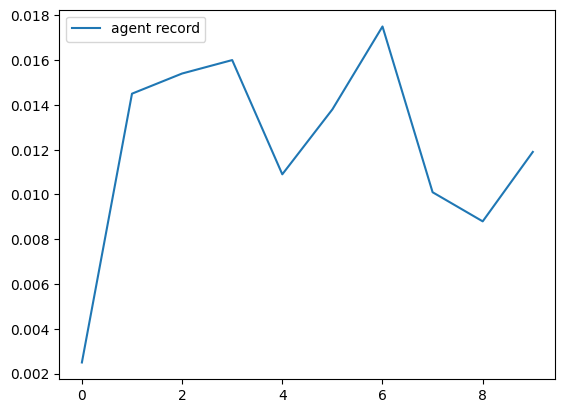


Number of bots: 5
Agent: <function markovian_agent2 at 0x12a7b37e0>
Agent record: 0.01303
Bot record: -0.004586
MSE: 1.6588800000000001
time...: [151. 100. 108. 173.  39. 300. 173.  14. 173.  72.]


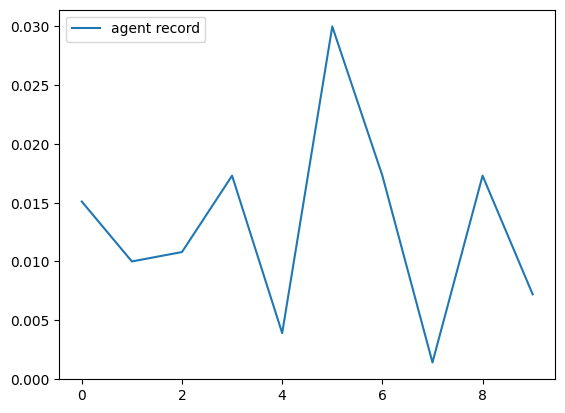


Number of bots: 10
Agent: <function markovian_agent2 at 0x12a7b37e0>
Agent record: 0.01609
Bot record: -0.0032310002
MSE: 1.15811
time...: [144. 245. 147. 117. 236. 125.  96. 144. 169. 186.]


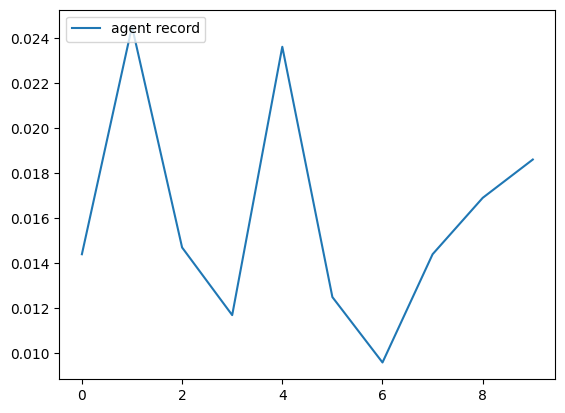

In [127]:
# agent 2
data = blackjack.read_data("blkjck_clean.csv")
for num_bots in [0, 1, 2, 5, 10]:
    evaluate_time_series(data, markov.markovian_agent2, num_bots, num_series=1000, bucket_size=10)

Number of bots: 1
Agent: <function markovian_agent3 at 0x12a7b3ce0>
Agent record: -0.050300002
Bot record: -0.0461
MSE: 9.3826
time...: [ -6.  -7.   9.   7. -10.  -7. -11. -10. -24. -17. -10.  -1.  16. -17.
  -4.  -1. -10. -22.  -8.  -4. -27.  24.  -7. -25.  -2.  -5.   6. -12.
 -18.   4.   2. -19.  12.  -4.   8.  -2. -13. -18.   5. -14.  12. -11.
  -3.   8.   0.   6.  10. -19.  -5.   6. -20.  -2.  -2.  19. -10. -10.
   4.   7.  -8.  -9.   7.  -3.   4.   3.  -7.  -8. -10. -17. -21. -11.
 -24. -31.  -8.   8. -12.  13.  -7. -17. -10. -10.  -1. -25. -11.  -1.
  -7.  16. -12.  -4.  17.  -3.  -5.   2.  -7.   3. -10.  -3. -14.   2.
 -11.   1.]


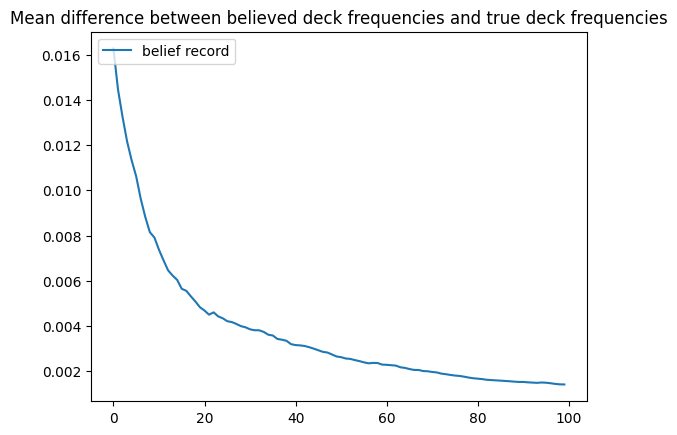

In [123]:
# agent 3
data = blackjack.read_data("blkjck_clean.csv")
for num_bots in [0, 1, 2, 5, 10]:
    evaluate_time_series(data, markov.markovian_agent3, num_bots, num_series=100, bucket_size = 1)